In [ ]:
import pandas as pd
df=pd.read_csv('agri_data.csv')
pd.set_option('display.expand_frame_repr',False)
print(df)

   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  Temperature_C
0  2018  North  Wheat           1200             3600          800             22
1  2018  South   Rice           1500             5000         1200             28
2  2019  North  Wheat           1250             3700          820             23
3  2019  South   Rice           1600             5200         1150             29
4  2020  North  Wheat           1300             3900          780             24
5  2020  South   Rice           1700             5400         1300             30
6  2021  North  Wheat           1280             4000          900             23
7  2021  South   Rice           1750             5600         1250             31
8  2022  North  Wheat           1350             4200          850             25
9  2022  South   Rice           1800             6000         1400             32


In [ ]:
print("total rows",len(df))

total rows 10


In [ ]:
print('total columns',len(df.columns))

total columns 7


In [ ]:
print("first five rows",df.head(5))

first five rows    Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  Temperature_C
0  2018  North  Wheat           1200             3600          800             22
1  2018  South   Rice           1500             5000         1200             28
2  2019  North  Wheat           1250             3700          820             23
3  2019  South   Rice           1600             5200         1150             29
4  2020  North  Wheat           1300             3900          780             24


In [ ]:
print("total production by year")
yearly_production=df.groupby('Year')['Production_Tons'].sum()
print(yearly_production)

total production by year
Year
2018     8600
2019     8900
2020     9300
2021     9600
2022    10200
Name: Production_Tons, dtype: int64


In [ ]:
print("data_info")
print(df.info())

data_info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             10 non-null     int64 
 1   Region           10 non-null     object
 2   Crop             10 non-null     object
 3   Area_Hectares    10 non-null     int64 
 4   Production_Tons  10 non-null     int64 
 5   Rainfall_mm      10 non-null     int64 
 6   Temperature_C    10 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 692.0+ bytes
None


In [ ]:
print("statistics")
print(df.describe())

statistics
              Year  Area_Hectares  Production_Tons  Rainfall_mm  Temperature_C
count    10.000000      10.000000        10.000000    10.000000      10.000000
mean   2020.000000    1473.000000      4660.000000  1045.000000      26.700000
std       1.490712     225.735834       875.848795   237.592087       3.713339
min    2018.000000    1200.000000      3600.000000   780.000000      22.000000
25%    2019.000000    1285.000000      3925.000000   827.500000      23.250000
50%    2020.000000    1425.000000      4600.000000  1025.000000      26.500000
75%    2021.000000    1675.000000      5350.000000  1237.500000      29.750000
max    2022.000000    1800.000000      6000.000000  1400.000000      32.000000


In [ ]:
df["Year"]

,Year
0,2018
1,2018
2,2019
3,2019
4,2020
5,2020
6,2021
7,2021
8,2022
9,2022


In [ ]:
wheat_data=df[df["Crop"]=="Wheat"]
print(wheat_data)


   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  Temperature_C
0  2018  North  Wheat           1200             3600          800             22
2  2019  North  Wheat           1250             3700          820             23
4  2020  North  Wheat           1300             3900          780             24
6  2021  North  Wheat           1280             4000          900             23
8  2022  North  Wheat           1350             4200          850             25


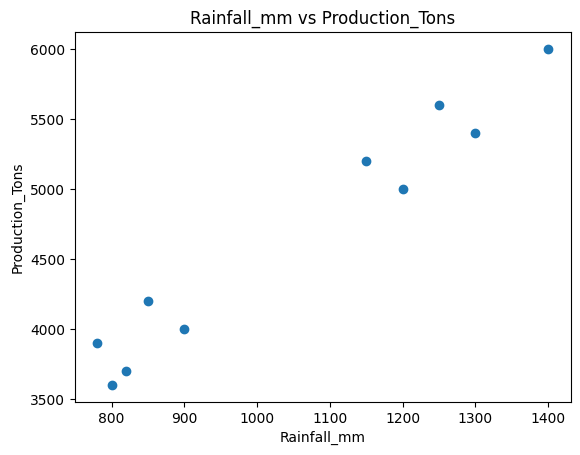

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall_mm'],df["Production_Tons"])
plt.xlabel("Rainfall_mm")
plt.ylabel("Production_Tons")
plt.title("Rainfall_mm vs Production_Tons")
plt.show()

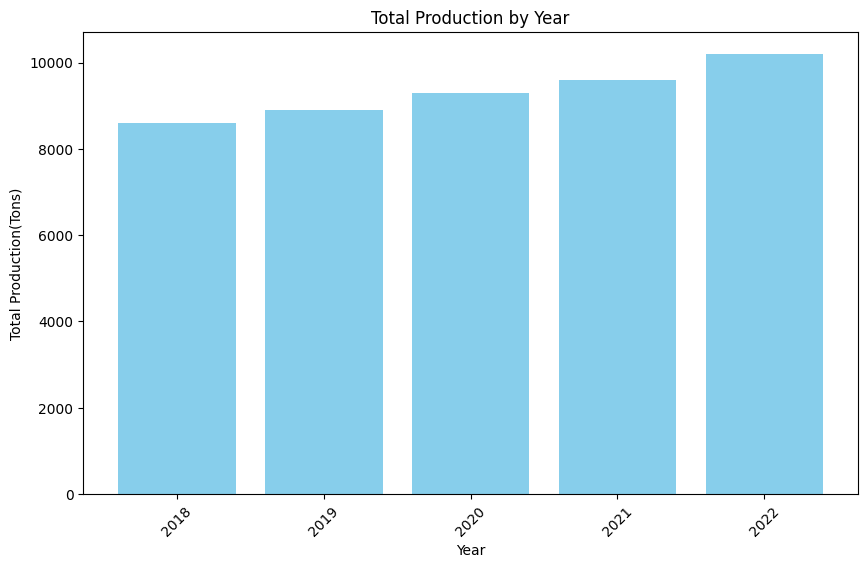

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(yearly_production.index,yearly_production.values,color='skyblue')
plt.xlabel("Year")
plt.ylabel("Total Production(Tons)")
plt.title("Total Production by Year")
plt.xticks(yearly_production.index,rotation=45)
plt.show()

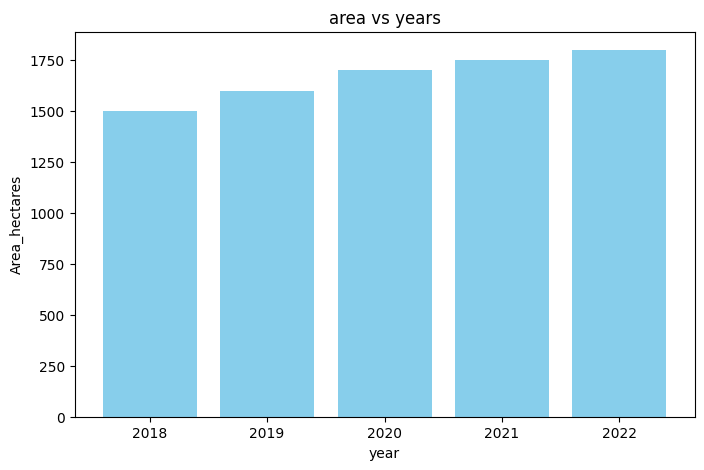

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df['Year'], df['Area_Hectares'], color='skyblue')
plt.xlabel('year')
plt.ylabel('Area_hectares')
plt.title('area vs years')
plt.show()

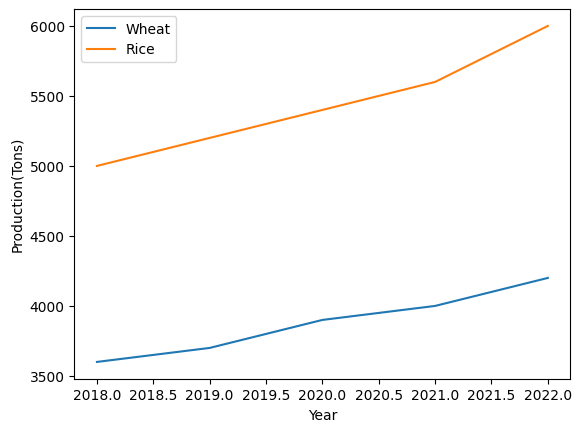

In [ ]:
wheat=df[df["Crop"]=="Wheat"]
rice=df[df["Crop"]=="Rice"]
plt.figure()
plt.plot(wheat["Year"],wheat["Production_Tons"],label="Wheat")
plt.plot(rice["Year"],rice["Production_Tons"],label="Rice")
plt.xlabel("Year")
plt.ylabel("Production(Tons)")
plt.legend()
plt.show()


In [ ]:
#Handling missing values
import pandas as pd
import numpy as np
data=pd.DataFrame({
    'plot':["A","B","C","D","E"],
    'yield_kg':[2500,np.nan,2800,np.nan,2600],
    'rainfall':[150,200,np.nan,180,170],
    'temprature':[28,30,29,np.nan,27],
    })
print("data with miossing values:")
print(data)
print("/n detecting missing values")
print("is null?")
print(data.isnull())
print("/n  total missing value per coloumn:")
print(data.isnull().sum())


data with miossing values:
  plot  yield_kg  rainfall  temprature
0    A    2500.0     150.0        28.0
1    B       NaN     200.0        30.0
2    C    2800.0       NaN        29.0
3    D       NaN     180.0         NaN
4    E    2600.0     170.0        27.0
/n detecting missing values
is null?
    plot  yield_kg  rainfall  temprature
0  False     False     False       False
1  False      True     False       False
2  False     False      True       False
3  False      True     False        True
4  False     False     False       False
/n  total missing value per coloumn:
plot          0
yield_kg      2
rainfall      1
temprature    1
dtype: int64


In [ ]:
#Filling missing values
print("filling stategies")
#Filling with mean
data_mean=data.copy()
print(data_mean['yield_kg'])
data_mean['yied_kg']=data_mean['yield_kg'].fillna(data_mean['yield_kg'].mean())
print("\nFill with mean:")
print(data_mean['yield_kg'])


filling stategies
0    2500.0
1       NaN
2    2800.0
3       NaN
4    2600.0
Name: yield_kg, dtype: float64

Fill with mean:
0    2500.0
1       NaN
2    2800.0
3       NaN
4    2600.0
Name: yield_kg, dtype: float64


In [ ]:
#dropping missing data
print("dropping rows")
data_dropped=data.dropna()
print(data_dropped)
print(f"original; rows:{len(data)} after drop:{len(data_dropped)}")

dropping rows
  plot  yield_kg  rainfall  temprature
0    A    2500.0     150.0        28.0
4    E    2600.0     170.0        27.0
original; rows:5 after drop:2
